# Global E-Waste Generation: A Focused Analysis on India

**Problem Statement:** Electronic waste (e-waste) is one of the fastest-growing waste
streams in the world. This notebook analyses a 20-country dataset of e-waste
generation, per-capita generation, population, and national policy frameworks for
the year 2022, with the goal of understanding **where India stands globally**,
**why it stands there**, and **what the data implies for policy going forward**.

Name:

      Vaishnavi Bagade(24101B0016)

      Yash Jadhav(24101B0068)

      Malhaar  NIkam(24101B0083)

**Workflow:**
1. Load the dataset
2. Clean and organise the data
3. Analyse it (descriptive statistics, correlation, regression)
4. Visualise key patterns
5. Extract insights and data-driven recommendations


## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 120)

# Colour palette: India is always highlighted in a distinct colour
INDIA_COLOR = "#FF6B35"
BASE_COLOR  = "#4C72B0"
GRID_COLOR  = "#BFBFBF"


## 2. Load the Dataset

Run the cell below in Google Colab. It will open a file-picker so you can upload
`global_ewaste_india_analysis.csv` directly. If the file is already sitting in the
Colab working directory (e.g. you mounted Drive or it's already uploaded), it will
just load it straight away.

In [ ]:
import os

FILENAME = "global_ewaste_india_analysis.csv"

if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        print("Please upload 'global_ewaste_india_analysis.csv' ...")
        uploaded = files.upload()
        FILENAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"'{FILENAME}' not found. Place it in the working directory, "
            "or run this in Google Colab to use the upload widget."
        )

df_raw = pd.read_csv(FILENAME)
print(f"Loaded {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
df_raw.head()


Loaded 20 rows and 15 columns.


,country,region,ewaste_generated_million_kg,ewaste_kg_per_capita,ewaste_recycled_million_kg,recycling_rate_percent,population_million,gdp_billion_usd,ewaste_per_billion_gdp,legislation,epr,collection_target,recycling_target,year,ewaste_generated_tonnes
0,India,Asia,4100,2.9,NaN,NaN,1417.0,NaN,NaN,Yes,Yes,Yes,Yes,2022,4100000
1,China,Asia,12000,8.5,NaN,NaN,1412.0,NaN,NaN,Yes,Yes,Yes,Yes,2022,12000000
2,United States,Americas,7700,23.9,NaN,NaN,333.3,NaN,NaN,Yes,Yes,Yes,Yes,2022,7700000
3,Japan,Asia,2600,20.6,NaN,NaN,125.1,NaN,NaN,Yes,Yes,Yes,Yes,2022,2600000
4,Germany,Europe,1700,20.3,NaN,NaN,84.1,NaN,NaN,Yes,Yes,Yes,Yes,2022,1700000


## 3. Clean and Organise the Dataset

### 3.1 Initial inspection

First, look at data types and, crucially, how much data is actually missing in
each column — this decides what can and can't be analysed.

In [ ]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      20 non-null     str    
 1   region                       20 non-null     str    
 2   ewaste_generated_million_kg  20 non-null     int64  
 3   ewaste_kg_per_capita         20 non-null     float64
 4   ewaste_recycled_million_kg   0 non-null      float64
 5   recycling_rate_percent       0 non-null      float64
 6   population_million           20 non-null     float64
 7   gdp_billion_usd              0 non-null      float64
 8   ewaste_per_billion_gdp       0 non-null      float64
 9   legislation                  20 non-null     str    
 10  epr                          20 non-null     str    
 11  collection_target            20 non-null     str    
 12  recycling_target             20 non-null     str    
 13  year                         20 n

In [ ]:
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_%', ascending=False)


,missing_count,missing_%
ewaste_recycled_million_kg,20,100.0
recycling_rate_percent,20,100.0
gdp_billion_usd,20,100.0
ewaste_per_billion_gdp,20,100.0


### 3.2 Cleaning decisions

The missingness check shows that **four columns are 100% empty** for every single
country: `ewaste_recycled_million_kg`, `recycling_rate_percent`, `gdp_billion_usd`,
and `ewaste_per_billion_gdp`. There is nothing to impute here — a mean/median fill
would fabricate data that doesn't exist, so these columns are **dropped**. This
itself is a finding worth carrying forward: actual recycling volumes and GDP
figures are not tracked/available in this dataset, which limits how far the
"circular economy" side of the story can be quantified.

Two more columns add no analytical value:
- `ewaste_generated_tonnes` is just `ewaste_generated_million_kg × 1,000,000` — a
  duplicate of an existing column in different units.
- `year` is constant (2022) across all rows, so it can't distinguish anything
  (kept out of the working frame, noted once here instead).

Everything else is cleaned and organised into `df`, sorted by total e-waste
generated (descending) so India's position is immediately visible.

In [ ]:
df = df_raw.drop(columns=[
    'ewaste_recycled_million_kg',
    'recycling_rate_percent',
    'gdp_billion_usd',
    'ewaste_per_billion_gdp',
    'ewaste_generated_tonnes',
])

# Standardise Yes/No policy columns into clean booleans (keep readable copies too)
policy_cols = ['legislation', 'epr', 'collection_target', 'recycling_target']
for c in policy_cols:
    df[c] = df[c].str.strip()
    df[c + '_bool'] = df[c].map({'Yes': True, 'No': False})

df['country'] = df['country'].str.strip()
df['region'] = df['region'].str.strip()

df = df.sort_values('ewaste_generated_million_kg', ascending=False).reset_index(drop=True)
df.insert(0, 'rank_by_total_ewaste', df.index + 1)

print("Duplicate rows:", df.duplicated(subset=['country']).sum())
print("Countries covered:", df['country'].nunique(), " | Year: 2022 (single-year snapshot)")
df


Duplicate rows: 0
Countries covered: 20  | Year: 2022 (single-year snapshot)


,rank_by_total_ewaste,country,region,ewaste_generated_million_kg,ewaste_kg_per_capita,population_million,legislation,epr,collection_target,recycling_target,year,legislation_bool,epr_bool,collection_target_bool,recycling_target_bool
0,1,China,Asia,12000,8.5,1412.0,Yes,Yes,Yes,Yes,2022,True,True,True,True
1,2,United States,Americas,7700,23.9,333.3,Yes,Yes,Yes,Yes,2022,True,True,True,True
2,3,India,Asia,4100,2.9,1417.0,Yes,Yes,Yes,Yes,2022,True,True,True,True
3,4,Japan,Asia,2600,20.6,125.1,Yes,Yes,Yes,Yes,2022,True,True,True,True
4,5,Brazil,Americas,2100,9.8,214.3,Yes,Yes,No,No,2022,True,True,False,False
5,6,Germany,Europe,1700,20.3,84.1,Yes,Yes,Yes,Yes,2022,True,True,True,True
6,7,Russia,Europe,1630,11.2,145.6,Yes,Yes,Yes,Yes,2022,True,True,True,True
7,8,United Kingdom,Europe,1600,24.5,67.3,Yes,Yes,Yes,Yes,2022,True,True,True,True
8,9,Indonesia,Asia,1600,5.9,275.5,Yes,Yes,No,No,2022,True,True,False,False
9,10,France,Europe,1400,21.0,66.0,Yes,Yes,Yes,Yes,2022,True,True,True,True


## 4. Analysis

### 4.1 Descriptive statistics

In [ ]:
df[['ewaste_generated_million_kg', 'ewaste_kg_per_capita', 'population_million']].describe().round(2)


,ewaste_generated_million_kg,ewaste_kg_per_capita,population_million
count,20.00,20.00,20.00
mean,2228.50,14.18,248.04
std,2828.54,7.37,407.41
min,480.00,2.30,26.30
25%,792.50,8.35,60.05
50%,1300.00,14.75,95.75
75%,1800.00,20.38,215.35
max,12000.00,24.50,1417.00


### 4.2 Where does India rank?

Two very different pictures emerge depending on whether e-waste is measured in
**absolute total** or **per person** — this contrast is the central story of the
dataset.

In [ ]:
india_total_rank = df.loc[df.country == 'India', 'rank_by_total_ewaste'].values[0]
total_n = len(df)

df_pc = df.sort_values('ewaste_kg_per_capita', ascending=False).reset_index(drop=True)
df_pc['rank_by_per_capita'] = df_pc.index + 1
india_pc_rank = df_pc.loc[df_pc.country == 'India', 'rank_by_per_capita'].values[0]

india_total = df.loc[df.country == 'India', 'ewaste_generated_million_kg'].values[0]
india_pc = df.loc[df.country == 'India', 'ewaste_kg_per_capita'].values[0]
global_avg_pc = df['ewaste_kg_per_capita'].mean()
top_pc_country = df_pc.iloc[0]

global_total = df['ewaste_generated_million_kg'].sum()
india_share = india_total / global_total * 100

print(f"India ranks #{india_total_rank} of {total_n} by TOTAL e-waste generated  -> {india_total:,} million kg ({india_share:.1f}% of this 20-country total)")
print(f"India ranks #{india_pc_rank} of {total_n} by PER-CAPITA e-waste generated -> {india_pc} kg/person")
print(f"Global average per-capita in this dataset: {global_avg_pc:.2f} kg/person")
print(f"Highest per-capita generator: {top_pc_country['country']} at {top_pc_country['ewaste_kg_per_capita']} kg/person "
      f"({top_pc_country['ewaste_kg_per_capita']/india_pc:.1f}x India's rate)")


India ranks #3 of 20 by TOTAL e-waste generated  -> 4,100 million kg (9.2% of this 20-country total)
India ranks #19 of 20 by PER-CAPITA e-waste generated -> 2.9 kg/person
Global average per-capita in this dataset: 14.18 kg/person
Highest per-capita generator: United Kingdom at 24.5 kg/person (8.4x India's rate)


### 4.3 What explains total e-waste? Population vs. affluence

Total e-waste should scale with population, but per-capita e-waste should reflect
consumption levels. A simple linear fit of *total e-waste ~ population* shows how
much of a country's total is "just because it's big" versus something else.

In [ ]:
corr_matrix = df[['population_million', 'ewaste_generated_million_kg', 'ewaste_kg_per_capita']].corr().round(2)
corr_matrix


,population_million,ewaste_generated_million_kg,ewaste_kg_per_capita
population_million,1.00,0.76,-0.45
ewaste_generated_million_kg,0.76,1.00,-0.03
ewaste_kg_per_capita,-0.45,-0.03,1.00


In [ ]:
slope, intercept = np.polyfit(df['population_million'], df['ewaste_generated_million_kg'], 1)
df['predicted_ewaste_from_population'] = slope * df['population_million'] + intercept
df['residual'] = df['ewaste_generated_million_kg'] - df['predicted_ewaste_from_population']

resid_sorted = df[['country', 'population_million', 'ewaste_generated_million_kg',
                    'predicted_ewaste_from_population', 'residual']].sort_values('residual')

print(f"Fitted trend: expected e-waste (million kg) ~= {slope:.2f} x population_million + {intercept:.0f}")
print()
print("Most 'under-predicted' countries (actual e-waste far BELOW what population alone predicts):")
resid_sorted.head(5).round(1)


Fitted trend: expected e-waste (million kg) ~= 5.30 x population_million + 914

Most 'under-predicted' countries (actual e-waste far BELOW what population alone predicts):


,country,population_million,ewaste_generated_million_kg,predicted_ewaste_from_population,residual
2,India,1417.0,4100,8421.9,-4321.9
18,Nigeria,218.5,500,2072.0,-1572.0
17,Egypt,106.2,510,1477.0,-967.0
8,Indonesia,275.5,1600,2374.0,-774.0
19,South Africa,60.4,480,1234.4,-754.4


### 4.4 Region-wise totals

In [ ]:
region_summary = df.groupby('region').agg(
    countries=('country', 'count'),
    total_ewaste_million_kg=('ewaste_generated_million_kg', 'sum'),
    avg_per_capita_kg=('ewaste_kg_per_capita', 'mean'),
).sort_values('total_ewaste_million_kg', ascending=False).round(2)

region_summary['share_of_20_country_total_%'] = (
    region_summary['total_ewaste_million_kg'] / region_summary['total_ewaste_million_kg'].sum() * 100
).round(1)

region_summary


,countries,total_ewaste_million_kg,avg_per_capita_kg,share_of_20_country_total_%
region,,,,
Asia,5,21100,10.68,47.3
Americas,4,11770,15.77,26.4
Europe,7,9630,18.59,21.6
Africa,3,1490,5.00,3.3
Oceania,1,580,22.00,1.3


### 4.5 Policy framework: legislation vs. actual enforcement targets

`legislation` is `Yes` for all 20 countries in this dataset, so on its own it can't
distinguish anything — every country claims *some* e-waste law. The more revealing
columns are whether that legislation comes with an **EPR (Extended Producer
Responsibility) mandate** and concrete **collection/recycling targets**.

In [ ]:
print("Countries where legislation exists but is NOT backed by a collection target:")
print(df.loc[~df.collection_target_bool, 'country'].tolist())
print()
print("Countries where legislation exists but is NOT backed by a recycling target:")
print(df.loc[~df.recycling_target_bool, 'country'].tolist())
print()
print("Countries without EPR:")
print(df.loc[~df.epr_bool, 'country'].tolist())
print()
print("India's own policy framework:")
df.loc[df.country == 'India', ['legislation', 'epr', 'collection_target', 'recycling_target']]


Countries where legislation exists but is NOT backed by a collection target:
['Brazil', 'Indonesia', 'Mexico', 'Egypt', 'Nigeria', 'South Africa']

Countries where legislation exists but is NOT backed by a recycling target:
['Brazil', 'Indonesia', 'Mexico', 'Egypt', 'Nigeria', 'South Africa']

Countries without EPR:
['Nigeria']

India's own policy framework:


,legislation,epr,collection_target,recycling_target
2,Yes,Yes,Yes,Yes


## 5. Visualisations

### 5.1 Total e-waste generated by country (India highlighted)

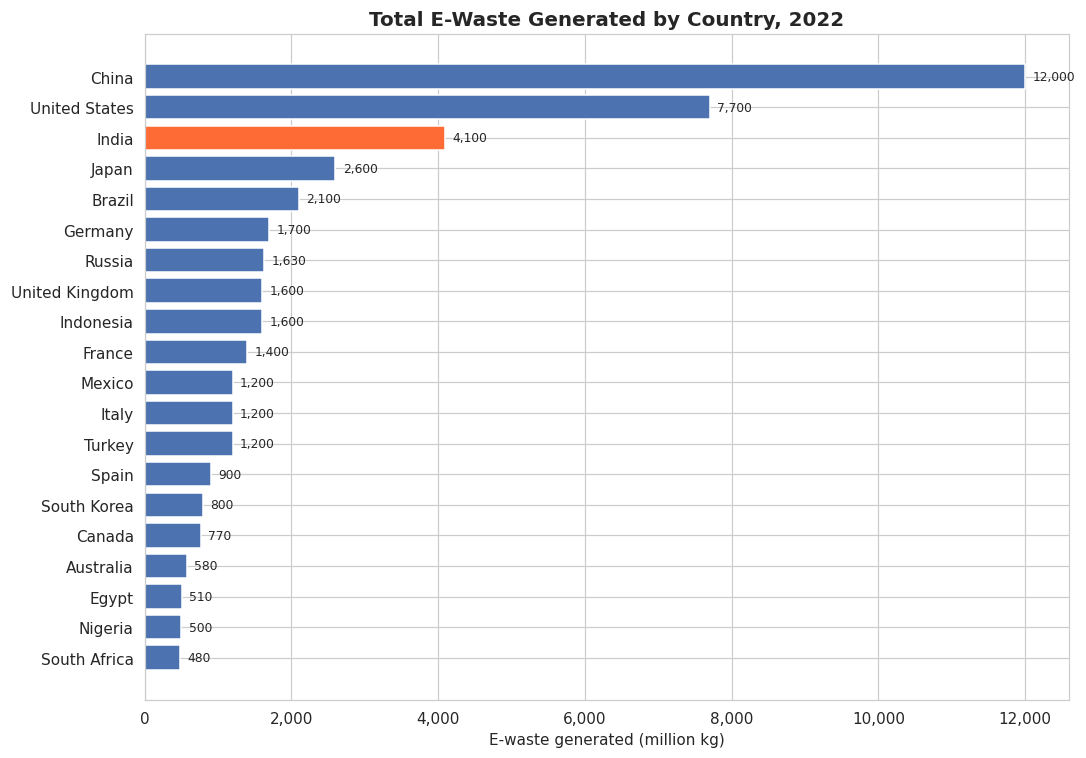

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = [INDIA_COLOR if c == 'India' else BASE_COLOR for c in df['country']]
bars = ax.barh(df['country'], df['ewaste_generated_million_kg'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('E-waste generated (million kg)')
ax.set_title('Total E-Waste Generated by Country, 2022', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, df['ewaste_generated_million_kg']):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


### 5.2 Per-capita e-waste generated by country (India highlighted)

This is the flip side of the chart above — and tells a very different story.

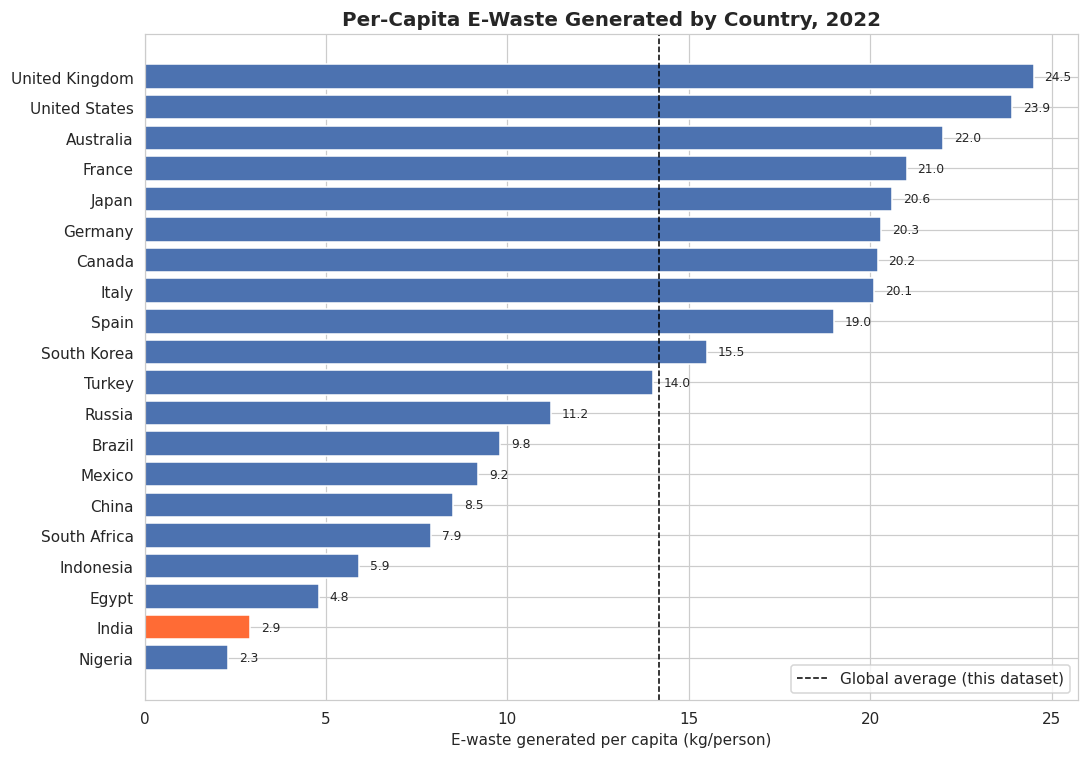

In [ ]:
df_pc_plot = df.sort_values('ewaste_kg_per_capita', ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
colors_pc = [INDIA_COLOR if c == 'India' else BASE_COLOR for c in df_pc_plot['country']]
bars = ax.barh(df_pc_plot['country'], df_pc_plot['ewaste_kg_per_capita'], color=colors_pc)
ax.invert_yaxis()
ax.axvline(df['ewaste_kg_per_capita'].mean(), color='black', linestyle='--', linewidth=1, label='Global average (this dataset)')
ax.set_xlabel('E-waste generated per capita (kg/person)')
ax.set_title('Per-Capita E-Waste Generated by Country, 2022', fontsize=13, fontweight='bold')
ax.legend()
for bar, val in zip(bars, df_pc_plot['ewaste_kg_per_capita']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=8)
plt.tight_layout()
plt.show()


### 5.3 Population vs. total e-waste (with trend line)

Highlights how far each country sits above or below what its population alone
would predict.

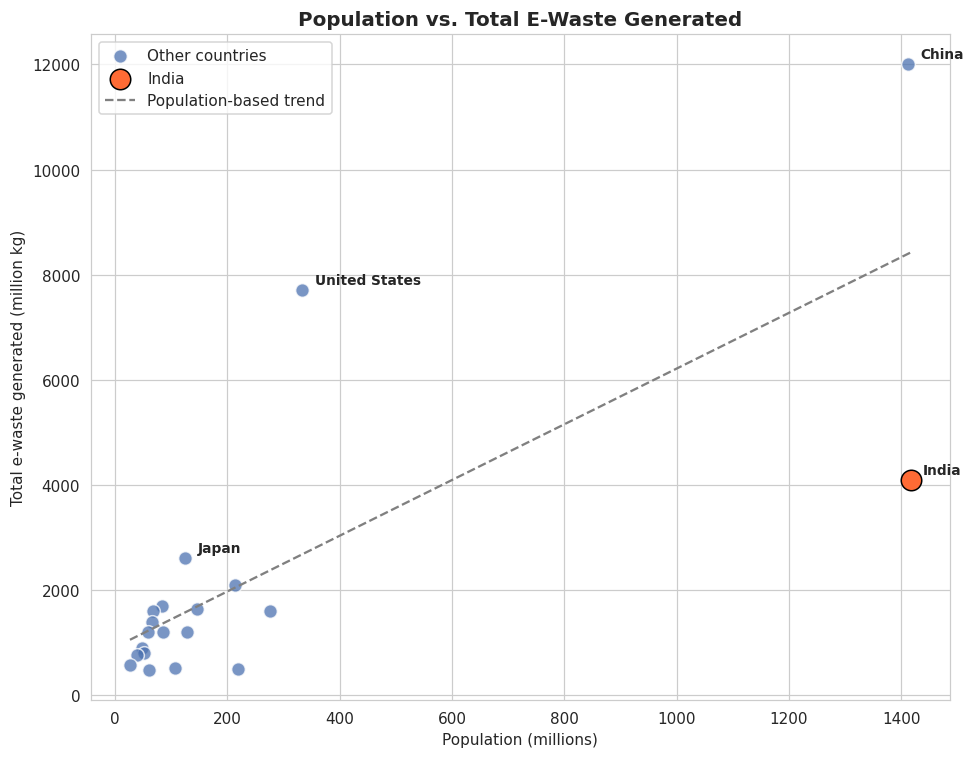

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
non_india = df[df.country != 'India']
india_row = df[df.country == 'India']

ax.scatter(non_india['population_million'], non_india['ewaste_generated_million_kg'],
           s=80, color=BASE_COLOR, alpha=0.75, edgecolor='white', label='Other countries')
ax.scatter(india_row['population_million'], india_row['ewaste_generated_million_kg'],
           s=180, color=INDIA_COLOR, edgecolor='black', zorder=5, label='India')

x_line = np.linspace(df['population_million'].min(), df['population_million'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='gray', linestyle='--', linewidth=1.5,
        label='Population-based trend')

for _, row in df.iterrows():
    if row['country'] in ['India', 'China', 'United States', 'Japan']:
        ax.annotate(row['country'], (row['population_million'], row['ewaste_generated_million_kg']),
                    textcoords="offset points", xytext=(8, 4), fontsize=9, fontweight='bold')

ax.set_xlabel('Population (millions)')
ax.set_ylabel('Total e-waste generated (million kg)')
ax.set_title('Population vs. Total E-Waste Generated', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### 5.4 Region-wise share of total e-waste

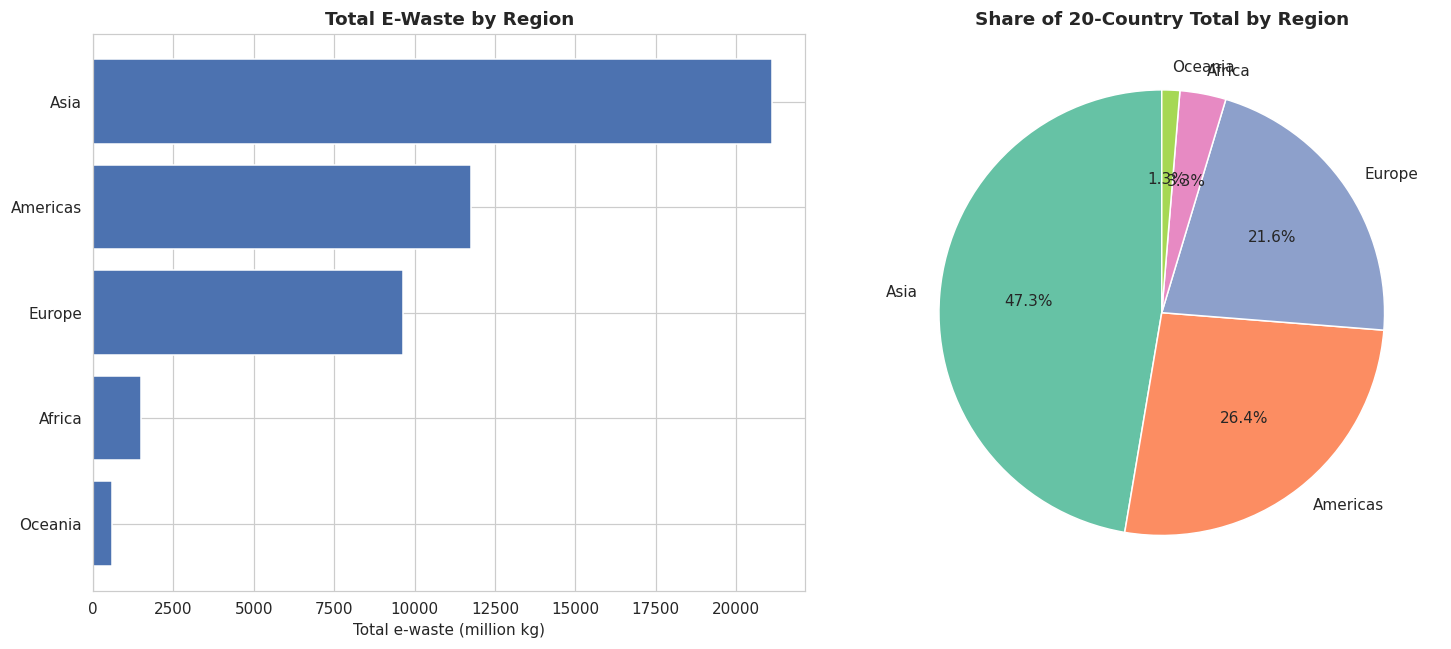

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

region_summary_sorted = region_summary.sort_values('total_ewaste_million_kg', ascending=True)
axes[0].barh(region_summary_sorted.index, region_summary_sorted['total_ewaste_million_kg'], color=BASE_COLOR)
axes[0].set_xlabel('Total e-waste (million kg)')
axes[0].set_title('Total E-Waste by Region', fontweight='bold')

axes[1].pie(region_summary['total_ewaste_million_kg'], labels=region_summary.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(region_summary)))
axes[1].set_title('Share of 20-Country Total by Region', fontweight='bold')

plt.tight_layout()
plt.show()


### 5.5 Policy gaps: which countries lack collection/recycling targets?

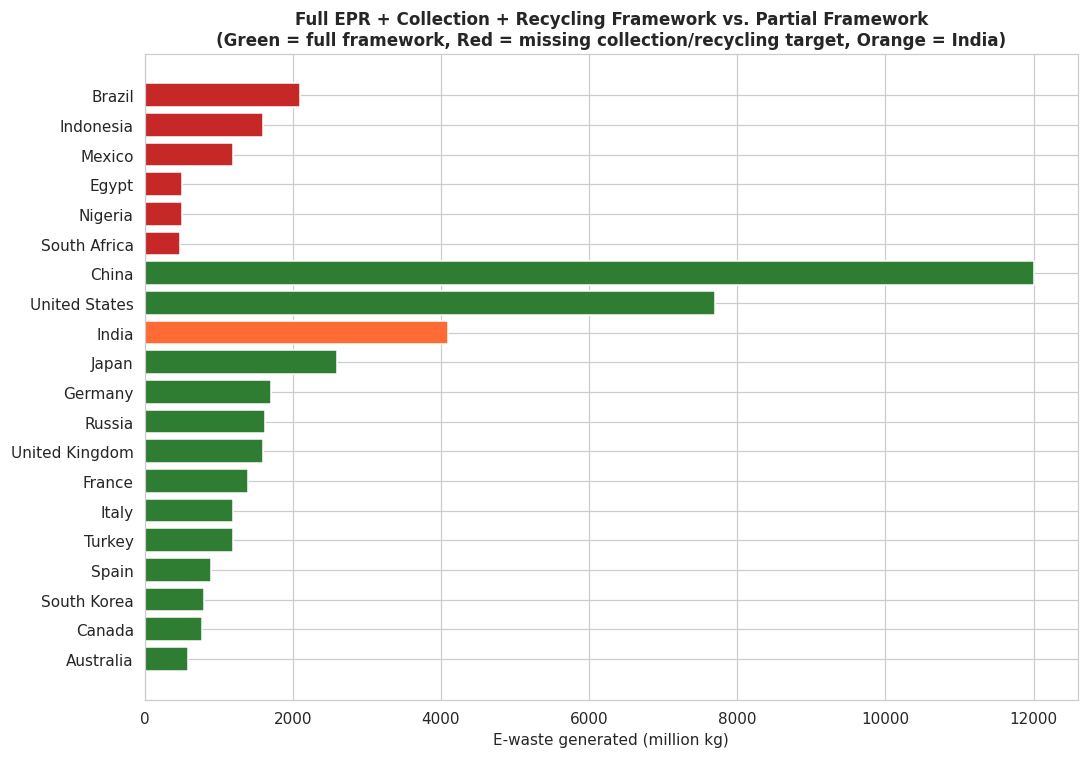

In [ ]:
gap_df = df.copy()
gap_df['has_full_framework'] = gap_df['collection_target_bool'] & gap_df['recycling_target_bool'] & gap_df['epr_bool']

fig, ax = plt.subplots(figsize=(10, 7))
colors_gap = [INDIA_COLOR if c == 'India' else ('#2E7D32' if full else '#C62828')
              for c, full in zip(gap_df['country'], gap_df['has_full_framework'])]
order = gap_df.sort_values(['has_full_framework', 'ewaste_generated_million_kg'], ascending=[True, False])
colors_gap_ordered = [INDIA_COLOR if c == 'India' else ('#2E7D32' if full else '#C62828')
                       for c, full in zip(order['country'], order['has_full_framework'])]

bars = ax.barh(order['country'], order['ewaste_generated_million_kg'], color=colors_gap_ordered)
ax.invert_yaxis()
ax.set_xlabel('E-waste generated (million kg)')
ax.set_title('Full EPR + Collection + Recycling Framework vs. Partial Framework\n(Green = full framework, Red = missing collection/recycling target, Orange = India)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.6 Correlation heatmap

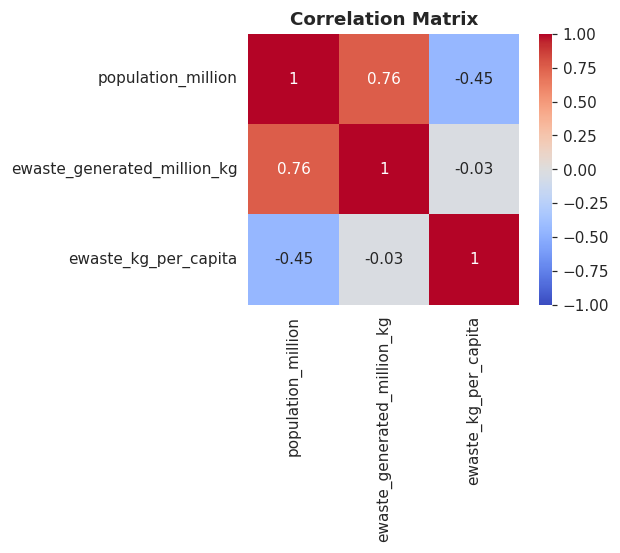

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=ax, square=True)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Key Insights & Findings

1. **India is the 3rd-largest total e-waste generator** among these 20 countries
   (4,100 million kg, 2022) — behind only China (12,000 million kg) and the
   United States (7,700 million kg) — accounting for roughly **9.2%** of the
   combined total for all 20 countries.

2. **But per person, India generates the least of any large economy** — 2.9
   kg/person, ranking **19th out of 20**, only just above Nigeria (2.3 kg/person).
   That is roughly **8x lower** than the United Kingdom (24.5 kg/person, the
   highest in the dataset) and about **5x lower** than the 20-country average
   (14.18 kg/person). India's massive population, not high consumption per
   person, is what drives its total ranking.

3. **India generates far less e-waste than its population alone would predict.**
   A simple population-based trend line predicts ~8,400 million kg for a country
   India's size — India's actual figure (4,100 million kg) is about **4,300
   million kg below** that line, the single largest shortfall of any country in
   the dataset. As electronics penetration and household income rise, this gap
   is a strong signal that India's e-waste volumes have significant **room — and
   likely reason — to grow substantially** in the coming years.

4. **Population size and per-capita generation move in opposite directions**
   (correlation ≈ **-0.45**), while population and *total* e-waste are positively
   correlated (≈ **0.76**). In other words, size explains the totals, but
   affluence/consumption — not population — explains the per-person rate.

5. **On paper, India already has a full policy framework**: legislation, EPR,
   a collection target, and a recycling target are all in place. This puts it
   ahead of several other major emerging-economy generators — **Brazil,
   Indonesia, Mexico, Egypt, Nigeria, and South Africa** all report basic
   e-waste legislation but **lack both collection and recycling targets**,
   and Nigeria lacks EPR entirely.

6. **Asia dominates total generation**: with just 5 countries (China, India,
   Japan, Indonesia, South Korea), the region accounts for **~47%** of the
   20-country total — more than the Americas and Europe combined.

7. **A real data gap**: `ewaste_recycled_million_kg`, `recycling_rate_percent`,
   and GDP-linked columns are **100% missing** for every country. This means
   the dataset can establish *how much e-waste is generated* and *what policy
   exists on paper*, but says nothing about **how much of it is actually
   recovered/recycled** — arguably the more important number for both India
   and the world.


## 7. Data-Driven Recommendations

- **Close the "framework-to-outcome" gap.** India has the legislative pieces
  (EPR, collection target, recycling target) that many peer emerging economies
  lack — the priority now is enforcement and, critically, **public recycling
  rate reporting**, so progress can actually be measured. Right now the
  recycling-rate data doesn't even exist in a dataset that otherwise tracks
  20 major economies in detail.

- **Plan capacity ahead of the population-driven growth curve.** Since India's
  e-waste output sits far below its "population-predicted" level, growth in
  generation is highly likely as incomes and device ownership rise. Formal
  collection and recycling infrastructure built *now*, while volumes are
  comparatively low, will be cheaper than retrofitting capacity after the
  gap closes.

- **Use policy leadership as diplomatic leverage.** Because India already
  has a fuller framework than several large emerging economies (Brazil,
  Indonesia, Mexico, Egypt, Nigeria, South Africa), it is well placed to
  lead South-South knowledge-sharing on EPR implementation and target-setting
  — turning a domestic regulatory head start into regional influence.

- **Target the informal-to-formal transition specifically**, since a country
  with India's per-capita profile (low reported per-person waste but a huge
  absolute volume) is a strong candidate for large amounts of e-waste being
  processed outside formal, measured channels — which would also explain why
  recycling-rate data is unavailable rather than merely low.

- **Fill the measurement gap before the next policy cycle.** Any future
  version of this kind of dataset should not have GDP and recycling-rate
  columns 100% empty — without them, e-waste generation can't be benchmarked
  against economic intensity or actual circularity, only against population
  and legislation type.


## 8. Limitations

- Single-year snapshot (2022) only — no time-series, so trends over time
  cannot be verified, only inferred from the population-residual analysis.
- Limited to 20 countries; not a full global sample.
- Recycling volumes, recycling rates, and GDP are entirely missing from the
  source data, so affluence-adjusted and circularity-adjusted analysis was
  not possible with this file alone.
